In [2]:
%pip install langchain langchain-community langchain-google-genai

  Using cached langchain-1.4.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langchain_google_genai-4.4.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached langgraph-1.2.11-py3-none-any.whl.metadata (4.9 kB)
  Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached langchain_text_splitters-1.1.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached google_genai-2.24.0-py3-none-any.whl.metadata (56 kB)
Using cached langchain-1.4.2-py3-none-any.whl (163 kB)
Using cached langgraph-1.2.11-py3-none-any.whl (248 kB)
Using cached langgraph_checkpoint-4.2.0-py3-none-any.whl (56 kB)
Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl (41 kB)
Using cached langgraph_sdk-

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Projects\\AI Agents Workshop\\Day 5\\.venv\\Lib\\site-packages\\langgraph_sdk\\_async\\store.py'
Check the permissions.



In [ ]:
import os

#os.environ["GEMINI_API_KEY"] = "your-api-key" I left it blank here, to push in github, you can add your api key

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite", temperature=0, max_tokens=2500, timeout=500.0, max_retries=3)

In [10]:
import sqlite3
from langchain.tools import tool

@tool
def get_student_info(student_id: str) -> str:
    """Return student name and department for a given student_id."""
    conn = sqlite3.connect("students.db")
    cursor = conn.cursor()
    cursor.execute("SELECT name, department FROM students WHERE student_id = ?", (student_id.strip(),))
    row = cursor.fetchone()
    conn.close()
    
    if not row:
        return f"Student {student_id} not found."
    return f"Name: {row[0]}, Department: {row[1]}"

@tool
def get_student_marks(student_id: str) -> str:
    """Return Python, Database, AI, and Web marks for a given student_id."""
    conn = sqlite3.connect("students.db")
    cursor = conn.cursor()
    cursor.execute("SELECT python, database, ai, web FROM students WHERE student_id = ?", (student_id.strip(),))
    row = cursor.fetchone()
    conn.close()
    
    if not row:
        return f"Student {student_id} not found."
    return f"Python: {row[0]}, Database: {row[1]}, AI: {row[2]}, Web: {row[3]}"

@tool
def calculator(expression: str) -> str:
    """Used to calculate total marks or average marks from a mathematical expression (e.g., '85+72+90+78' or '(85+72+90+78)/4')."""
    try:
        allowed_chars = set("0123456789+-*/(). ")
        if not set(expression).issubset(allowed_chars):
            return "Error: Expression contains invalid characters."
        result = eval(expression, {"__builtins__": None}, {})
        return str(result)
    except Exception as e:
        return f"Error evaluating expression: {str(e)}"

@tool
def get_passing_rules() -> str:
    """Return the university passing rules."""
    return (
        "University Passing Rules:\n"
        "- Minimum overall average: 40%\n"
        "- Minimum mark in each subject: 35%"
    )

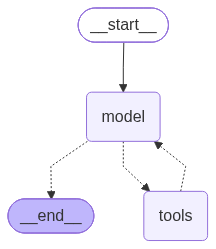

In [6]:
from langchain.agents import create_agent

agent = create_agent(
    model = llm,
    tools = [get_student_info, get_student_marks, calculator, get_passing_rules],
    system_prompt = """You are the Academic Student Assistant.
Use the appropriate tools to look up student facts, marks, calculator functions, and passing rules.
Do not guess any data.
For passing eligibility check:
1. Retrieve student marks using get_student_marks.
2. Calculate total and average marks using calculator.
3. Check passing requirements using get_passing_rules.
4. Verify if every subject mark is >= 35% and the overall average is >= 40%.
Keep replies clear, concise, and structured."""
)
agent

In [11]:
question = input("what's your query:")

result = agent.invoke({
    "messages": [
        {
            "role": "system",
            "content": "The user is asking an academic question regarding student records."
        },
        {
            "role": "user",
            "content": question
        }
    ]
})

answer = result["messages"][-1].content
if isinstance(answer, list):
    answer = "\n".join(
        item["text"]
        for item in answer
        if isinstance(item, dict) and item.get("type") == "text"
    )

print("\n" + "*" * 60)
print(" STUDENT ACADEMIC AGENT ANSWER")
print(answer)
print("*" * 60)

c:\Projects\AI Agents Workshop\Day 5\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Projects\AI Agents Workshop\Day 5\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Projects\AI Agents Workshop\Day 5\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



************************************************************
 STUDENT ACADEMIC AGENT ANSWER
- **Name:** Dhanushya
- **Department:** Computer Science
- **Total Marks:** 325
- **Average Marks:** 81.25%
- **Passing Status:** Yes, you satisfy the university passing requirements (all subject marks are $\ge$ 35% and the overall average is $\ge$ 40%).
************************************************************
